# 05 · Scenarios: one change in prices, carried through every actor

The simulator answers the question a pricing team asks before touching a rate: **if this
changes, who ends up paying for it?** It chains everything the earlier features built, once, for
a change written as YAML in `config/scenarios/`:

1. **Price.** The scenario's levers change interchange, split migrated volume or take purchases
   off the card rails, and every transaction of the base year is priced again.
2. **Pass-through.** Acquirers move blended rates by half the change in interchange, and issuers
   move rewards by half of theirs. IC++ merchants see the whole change.
3. **Abandonment.** Each merchant's new relative burden goes through the calibrated curve; a
   scenario costs only the extra abandonment its prices cause.
4. **Redistribution.** That volume moves to the merchant's substitutes, after a share leaks off
   the card rails.
5. **Spend.** Cardholders answer the new rewards rate.
6. **P&L.** Every actor, against the base year.

The base year is 2025 as it happened, so each scenario reads as *how 2025 would have looked with
different prices*. The null scenario reproduces it exactly.

> **Synthetic data.** The pass-through shares, the curve's anchors and the size of each scenario
> are assumptions of our own ([P] in `docs/assumptions.md`). The point is the machinery and the
> direction of each effect, not the figures. Run `python -m ips.simulator run --all` first: this
> notebook reads its results.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.ticker import PercentFormatter

from ips.simulator.cli import SCENARIO_ARTIFACTS
from ips.simulator.scenario import load_scenario, scenario_paths
from ips.simulator.sensitivity import sweep, tornado
from ips.simulator.state import load_state
from ips.utils.config import load_config
from ips.utils.io import artifacts_dir

pl.Config.set_thousands_separator(",")
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_width_chars(190)
pl.Config.set_tbl_cols(12)
pl.Config.set_fmt_str_lengths(60)
start = time.perf_counter()
cfg = load_config()

directory = artifacts_dir(cfg) / SCENARIO_ARTIFACTS
if not (directory / "summary.parquet").exists():
    raise FileNotFoundError(
        "Run `python -m ips.simulator run --all` first: this notebook reads it."
    )
summary = pl.read_parquet(directory / "summary.parquet")
parts = ("totals", "by_actor", "bridge", "acceptance", "prices")
tables = {
    name: {part: pl.read_parquet(directory / name / f"{part}.parquet") for part in parts}
    for name in summary["scenario"]
}
sorted(tables)

['baseline',
 'cnp_tokenized_discount',
 'instant_payments_entry',
 'premium_migration',
 'regulatory_cap_credit',
 'regulatory_cap_debit',
 'strategic_merchant_deal']

Chart style: the dataviz reference palette, as in notebooks 01 to 04. Categorical colours
in a fixed order and the neutral grey reserved for reference lines.

In [2]:
SURFACE, INK, INK_2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # categorical slots 1-4, fixed order
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "figure.dpi": 110,
        "font.family": "sans-serif",
        "font.size": 10,
        "axes.edgecolor": AXIS,
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.axisbelow": True,
        "axes.titlelocation": "left",
        "axes.titlepad": 12,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "grid.linestyle": "-",
        "xtick.color": AXIS,
        "ytick.color": AXIS,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "legend.frameon": False,
        "legend.labelcolor": INK_2,
        "lines.linewidth": 2,
        "lines.solid_capstyle": "round",
    }
)
SCENARIO_LABEL = {
    "regulatory_cap_debit": "Debit cap at 0.3%",
    "regulatory_cap_credit": "Consumer credit cap at 0.5%",
    "instant_payments_entry": "Instant payments take 20% of small debit",
    "strategic_merchant_deal": "Largest merchant gets 25% off",
    "premium_migration": "10% of standard credit moves to premium",
    "cnp_tokenized_discount": "Tokenized CNP drops the CNP add-on",
}
PARAMETER_LABEL = {
    "simulator.blended_pass_through": "Pass-through to blended MDR (0 to 100%)",
    "simulator.rewards_pass_through": "Pass-through to rewards (0 to 100%)",
    "elasticity.redistribution.leakage_share": "Leakage off the card rails (20% to 50%)",
    "elasticity.acceptance.target_semi_elasticity": "Acceptance lost per +10% MDR (0.9 to 2.7 pp)",
    "elasticity.acceptance.level_burden_exponent": "Group levels follow burden (exponent 0 to 1)",
}
ORDER = [name for name in SCENARIO_LABEL if name in tables]
standard = summary.filter(pl.col("scenario").is_in(ORDER))
INDEXED = {row["scenario"]: row for row in standard.iter_rows(named=True)}


def rounded(expression: pl.Expr, decimals: int) -> pl.Expr:
    # A tiny negative rounds to -0.0, which prints with its sign; show it as the zero it is.
    value = expression.round(decimals)
    return pl.when(value == 0).then(0.0).otherwise(value)

## 1 · The base year

2025 as it happened: what every scenario is read against. The null scenario (`baseline.yaml`)
reproduces these figures exactly.

In [3]:
base = tables["baseline"]["totals"]
assert (base["change"] == 0.0).all(), "the null scenario must reproduce the base year"
purchases = base.filter(pl.col("metric") == "n_txns")["baseline"].item()
print(f"{purchases / 1e6:.2f} million purchases")
base.filter(pl.col("metric") != "n_txns").select(
    "metric", (pl.col("baseline") / 1e9).round(3).alias("cop_billions")
)

3.26 million purchases


metric,cop_billions
str,f64
"""gdv_cop""",546.18
"""interchange_cop""",8.371
"""mdr_cop""",11.451
"""network_revenue_cop""",1.534
"""issuer_gross_cop""",7.924
"""acquirer_gross_cop""",1.993
"""rewards_cop""",2.099
"""issuer_contribution_cop""",3.824
"""acquirer_contribution_cop""",1.121


## 2 · The six scenarios, one sentence each

Every headline is written from the numbers. The chart puts the four actors side by side: a
change that looks small for the network can be large for the issuers who fund it.

In [4]:
for name in ORDER:
    print(f"- {INDEXED[name]['headline']}")
standard.select(
    "scenario",
    "network_revenue_change_pct",
    "issuer_contribution_change_pct",
    "acquirer_contribution_change_pct",
    "merchant_cost_change_pct",
    "gdv_change_pct",
    "seconds",
)

- Debit interchange is capped at 0.3% of every purchase. Network revenue +0.39%, issuer contribution -41.18%, acquirer contribution +46.95%, merchant cost -8.24% and card volume +0.33%.
- Consumer credit interchange is capped at 0.5% of every purchase; commercial cards stay exempt. Network revenue +0.79%, issuer contribution -50.45%, acquirer contribution +105.15%, merchant cost -17.16% and card volume +0.38%.
- Instant payments take 20% of debit purchases under COP 50,000 off the card rails. Network revenue -2.49%, issuer contribution -0.48%, acquirer contribution -0.19%, merchant cost -0.81% and card volume -1.05%.
- The largest merchant negotiates 25% off its interchange. Network revenue -0.00%, issuer contribution -1.19%, acquirer contribution +0.00%, merchant cost -0.63% and card volume +0.01%.
- 10% of standard credit volume moves to premium cards. Network revenue -0.03%, issuer contribution -0.50%, acquirer contribution -1.42%, merchant cost +0.24% and card volume -0.02%.
- Toke

scenario,network_revenue_change_pct,issuer_contribution_change_pct,acquirer_contribution_change_pct,merchant_cost_change_pct,gdv_change_pct,seconds
str,f64,f64,f64,f64,f64,f64
"""cnp_tokenized_discount""",0.000654,-0.05701,0.090756,-0.015645,0.000537,4.043335
"""instant_payments_entry""",-0.024921,-0.004763,-0.001853,-0.008091,-0.010489,3.675236
"""premium_migration""",-0.000286,-0.004953,-0.014172,0.002366,-0.000205,4.53759
"""regulatory_cap_credit""",0.007871,-0.5045,1.051509,-0.17164,0.003844,4.047898
"""regulatory_cap_debit""",0.003869,-0.411806,0.469494,-0.082385,0.003268,3.948864
"""strategic_merchant_deal""",-0.000013,-0.011869,0.000031,-0.006334,0.000077,3.60567


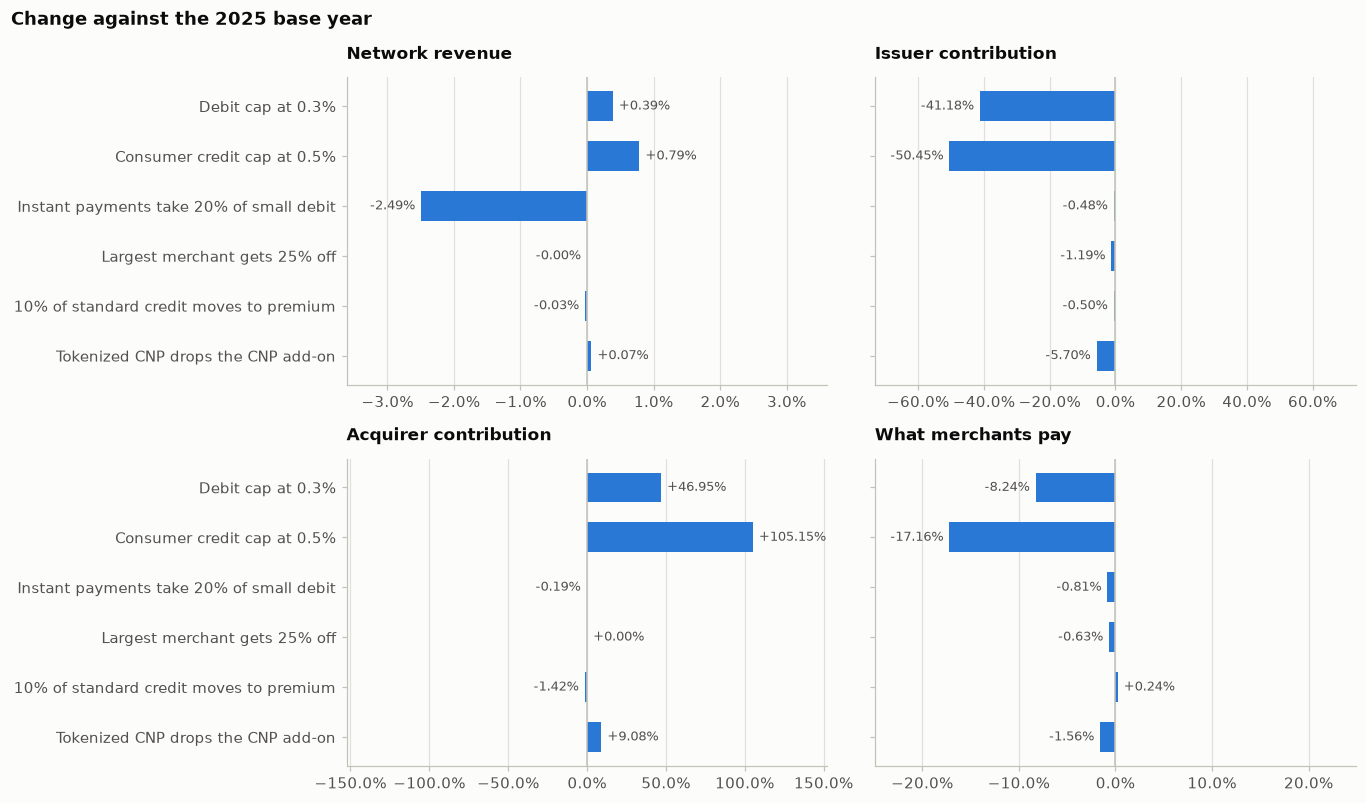

In [5]:
panels = (
    ("network_revenue_change_pct", "Network revenue"),
    ("issuer_contribution_change_pct", "Issuer contribution"),
    ("acquirer_contribution_change_pct", "Acquirer contribution"),
    ("merchant_cost_change_pct", "What merchants pay"),
)
positions = np.arange(len(ORDER))
fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.4), sharey=True)
for axis, (column, title) in zip(axes.ravel(), panels, strict=True):
    values = np.array([INDEXED[name][column] for name in ORDER])
    axis.barh(positions, values, color=SERIES[0], height=0.6)
    axis.axvline(0, color=AXIS, linewidth=1)
    limit = max(float(np.abs(values).max()) * 1.45, 1e-4)
    axis.set_xlim(-limit, limit)
    axis.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=1))
    axis.set_title(title, fontsize=11)
    axis.grid(axis="y", visible=False)
    for y, value in zip(positions, values, strict=True):
        axis.annotate(
            f"{value:+.2%}",
            xy=(value, y),
            xytext=(4 if value >= 0 else -4, 0),
            textcoords="offset points",
            ha="left" if value >= 0 else "right",
            va="center",
            fontsize=8.5,
            color=INK_2,
        )
for axis in axes[:, 0]:
    axis.set_yticks(positions, [SCENARIO_LABEL[name] for name in ORDER])
axes[0, 0].invert_yaxis()
fig.suptitle("Change against the 2025 base year", x=0.01, ha="left", fontweight="bold", color=INK)
fig.tight_layout()
plt.show()

## 3 · What moves network revenue

The network's fees do not depend on interchange: it charges each side a share of the amount plus
a fixed fee per purchase, and several times more per peso on cross-border purchases. So a change
in prices reaches the network only through how much volume stays on cards and where it lands. The
revenue bridge splits each change with Shapley values into volume, cross-border share, mix and
rate; the four effects add up exactly to the change.

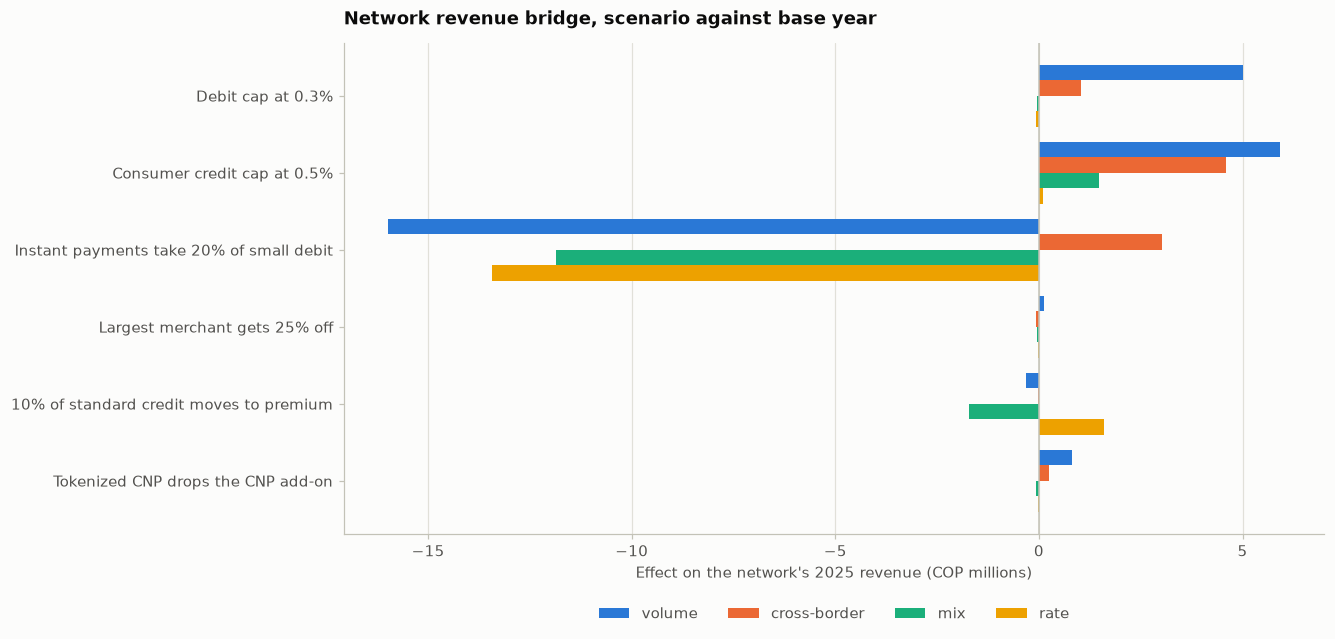

scenario,volume_m,cross_border_m,mix_m,rate_m,change_m
str,f64,f64,f64,f64,f64
"""regulatory_cap_debit""",5.02,1.03,-0.04,-0.07,5.94
"""regulatory_cap_credit""",5.91,4.58,1.48,0.11,12.08
"""instant_payments_entry""",-15.98,3.03,-11.86,-13.44,-38.24
"""strategic_merchant_deal""",0.12,-0.08,-0.04,-0.02,-0.02
"""premium_migration""",-0.31,-0.02,-1.71,1.6,-0.44
"""cnp_tokenized_discount""",0.82,0.25,-0.06,-0.01,1.0


In [6]:
drivers = ("volume", "cross_border", "mix", "rate")
effects = pl.DataFrame(
    [
        {"scenario": name}
        | {row["step"]: row["value_cop"] for row in tables[name]["bridge"].iter_rows(named=True)}
        for name in ORDER
    ]
)
positions = np.arange(len(ORDER))
height = 0.2
fig, axis = plt.subplots(figsize=(11.5, 5.8))
for index, (driver, colour) in enumerate(zip(drivers, SERIES, strict=True)):
    axis.barh(
        positions + (index - 1.5) * height,
        effects[driver].to_numpy() / 1e6,
        height=height,
        color=colour,
        label=driver.replace("_", "-"),
    )
axis.axvline(0, color=AXIS, linewidth=1)
axis.set_yticks(positions, [SCENARIO_LABEL[name] for name in ORDER])
axis.invert_yaxis()
axis.grid(axis="y", visible=False)
axis.set_xlabel("Effect on the network's 2025 revenue (COP millions)")
axis.set_title("Network revenue bridge, scenario against base year")
axis.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4)
plt.show()
effects.select(
    "scenario",
    *((pl.col(driver) / 1e6).round(2).alias(f"{driver}_m") for driver in drivers),
    ((pl.col("new") - pl.col("base")) / 1e6).round(2).alias("change_m"),
)

Read in this synthetic network, the caps add revenue through volume, because cheaper cards
keep merchants who would have dropped them, and through the cross-border share: the merchants
that keep proportionally more of their volume are the ones with more cross-border purchases,
where the network earns the most per peso. Instant payments are the mirror image. The purchases
that leave are small domestic debit, so the network loses volume and the fixed fee that weighs
most on small tickets (rate and mix), and its cross-border share rises only because domestic
volume shrinks.

## 4 · Who reacts, and where the volume goes

The first table keeps the books of acceptance: the volume merchants lose (negative when cheaper
prices keep merchants who would have dropped the card), what moves to substitutes, what leaks off
the card rails, and the net change in merchants expected to drop the card.

Instant payments and the premium migration are the two scenarios where abandonment rises. For
instant payments that follows from how burden is measured, not from a price change: debit, the
cheapest card, leaves, so the average rate of what stays on cards goes up even though merchants
pay less in total.

The second table shows what the pass-through rules did to prices, in basis points: blended rates
by MCC group and rewards rates by product. Scenarios that change no rate still move blended rates
a little: acquirers price blended merchants on the average interchange of their group, and the mix
of cards changes. Debit pays no rewards, and it does not start paying them when its average
interchange rises.

In [7]:
standard.select(
    "scenario",
    (pl.col("volume_lost_cop") / 1e6).round(1).alias("lost_m"),
    (pl.col("volume_moved_cop") / 1e6).round(1).alias("moved_m"),
    (pl.col("volume_leaked_cop") / 1e6).round(1).alias("leaked_m"),
    rounded(pl.col("net_merchants_abandoning"), 1).alias("net_merchants_abandoning"),
)

scenario,lost_m,moved_m,leaked_m,net_merchants_abandoning
str,f64,f64,f64,f64
"""cnp_tokenized_discount""","-1,137.0",-738.7,-398.3,-24.3
"""instant_payments_entry""",214.4,139.3,75.1,30.8
"""premium_migration""",282.4,183.5,98.9,18.1
"""regulatory_cap_credit""","-11,190.1","-7,269.7","-3,920.4",-484.1
"""regulatory_cap_debit""","-5,093.2","-3,308.4","-1,784.8",-177.2
"""strategic_merchant_deal""",-244.9,-159.2,-85.7,0.0


In [8]:
SHORT = {
    "regulatory_cap_debit": "debit_cap",
    "regulatory_cap_credit": "credit_cap",
    "instant_payments_entry": "instant",
    "strategic_merchant_deal": "strategic",
    "premium_migration": "premium",
    "cnp_tokenized_discount": "tokenized",
}
pl.concat(
    [tables[name]["prices"].with_columns(pl.lit(SHORT[name]).alias("case")) for name in ORDER]
).with_columns(
    (pl.col("base") * 1e4).round(1).alias("base_bp"),
    rounded((pl.col("scenario") - pl.col("base")) * 1e4, 1).alias("change_bp"),
).pivot(on="case", index=["price", "key", "base_bp"], values="change_bp")

price,key,base_bp,debit_cap,credit_cap,instant,strategic,premium,tokenized
str,str,f64,f64,f64,f64,f64,f64,f64
"""blended_mdr_rate""","""grocery""",160.0,-3.2,-16.2,1.4,0.0,0.6,-0.4
"""blended_mdr_rate""","""fuel""",155.0,0.0,-15.9,0.7,0.0,0.3,0.0
"""blended_mdr_rate""","""utilities_telecom""",165.0,-6.1,-18.4,0.3,0.0,0.3,-4.1
"""blended_mdr_rate""","""restaurants""",215.0,-16.1,-27.0,1.4,0.0,0.6,-0.7
"""blended_mdr_rate""","""health""",180.0,-9.2,-21.6,0.4,0.0,0.4,-0.4
"""blended_mdr_rate""","""retail""",220.0,-19.6,-37.9,0.2,0.0,0.5,-1.9
"""blended_mdr_rate""","""home_electronics""",215.0,-21.2,-27.6,0.0,0.0,0.4,-2.0
"""blended_mdr_rate""","""travel""",270.0,-15.4,-57.7,0.0,0.0,0.5,-5.0
"""blended_mdr_rate""","""transport""",200.0,-3.5,-20.0,4.0,0.0,1.3,-2.7


## 5 · How much the conclusions lean on the pass-through

Nobody publishes how much of an interchange cut acquirers pass to blended merchants or issuers
take out of rewards, and the split decides who absorbs a cap. So instead of trusting the 50 %
default, the credit cap is run again across the whole range. The dashed line marks the
default, and each panel has its own scale: the network's change is two orders of magnitude
smaller than the issuers'.

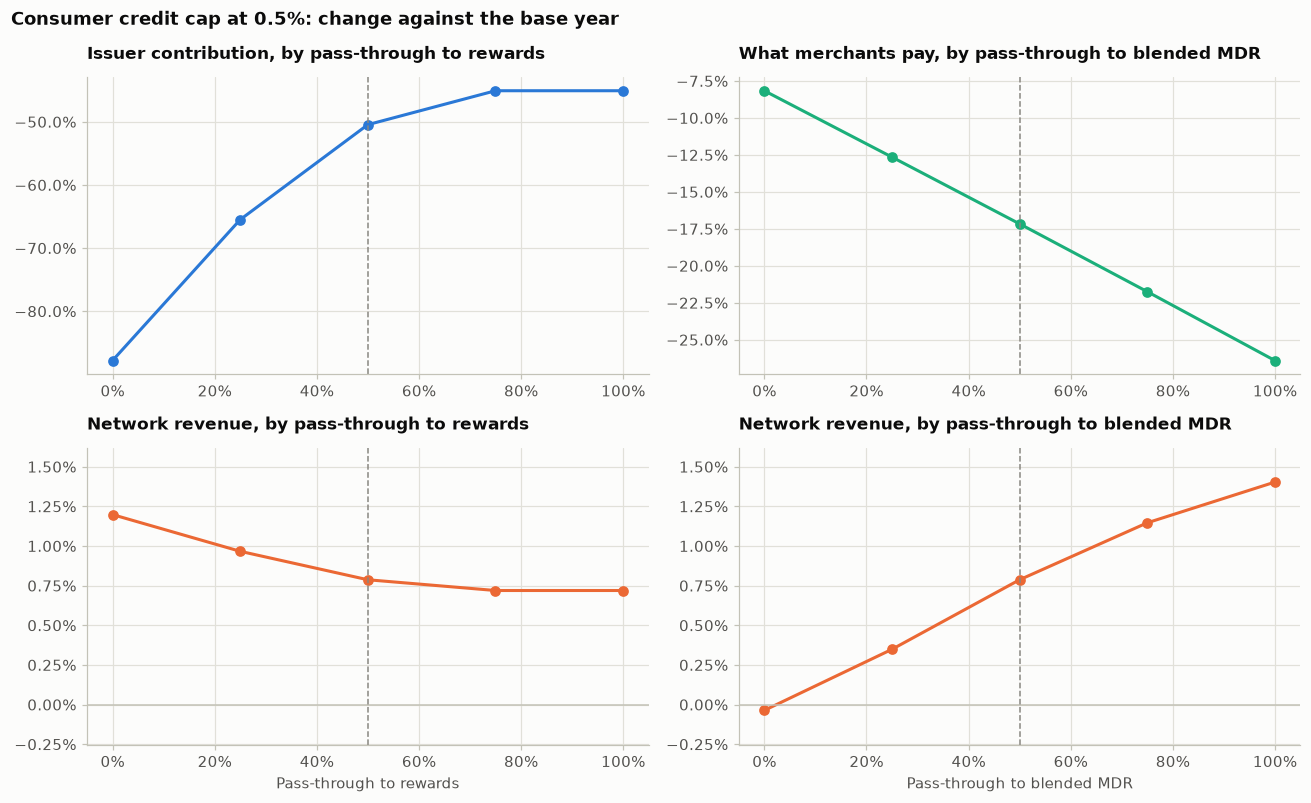

parameter,value,issuer_contribution_change_pct,merchant_cost_change_pct,network_revenue_change_pct
str,f64,f64,f64,f64
"""simulator.rewards_pass_through""",0.0,-0.878114,-0.168798,0.01198
"""simulator.rewards_pass_through""",0.25,-0.654943,-0.170428,0.009665
"""simulator.rewards_pass_through""",0.5,-0.5045,-0.17164,0.007871
"""simulator.rewards_pass_through""",0.75,-0.450766,-0.172091,0.007193
"""simulator.rewards_pass_through""",1.0,-0.450766,-0.172091,0.007193
"""simulator.blended_pass_through""",0.0,-0.504745,-0.081605,-0.000366
"""simulator.blended_pass_through""",0.25,-0.504466,-0.126482,0.003484
"""simulator.blended_pass_through""",0.5,-0.5045,-0.17164,0.007871
"""simulator.blended_pass_through""",0.75,-0.504607,-0.217488,0.011462


In [9]:
state = load_state(cfg)
credit_cap = load_scenario(
    next(path for path in scenario_paths(cfg) if path.stem == "regulatory_cap_credit"), cfg
)
values = [0.0, 0.25, 0.5, 0.75, 1.0]
sweeps = {
    parameter: sweep(state, credit_cap, parameter, values)
    for parameter in ("simulator.rewards_pass_through", "simulator.blended_pass_through")
}
panels = (
    ("rewards_pass_through", "rewards", "issuer_contribution_change_pct", "Issuer contribution"),
    ("blended_pass_through", "blended MDR", "merchant_cost_change_pct", "What merchants pay"),
)
network = pl.concat([frame["network_revenue_change_pct"] for frame in sweeps.values()])
span = network.max() - min(network.min(), 0.0)
fig, axes = plt.subplots(2, 2, figsize=(12, 7.4))
for column, (field, price, metric, label) in enumerate(panels):
    frame = sweeps[f"simulator.{field}"]
    top, bottom = axes[0, column], axes[1, column]
    top.plot(frame["value"], frame[metric], color=SERIES[0 if column == 0 else 2], marker="o")
    bottom.plot(frame["value"], frame["network_revenue_change_pct"], color=SERIES[1], marker="o")
    bottom.axhline(0, color=AXIS, linewidth=1)
    bottom.set_ylim(min(network.min(), 0.0) - 0.15 * span, network.max() + 0.15 * span)
    top.set_title(f"{label}, by pass-through to {price}", fontsize=11)
    bottom.set_title(f"Network revenue, by pass-through to {price}", fontsize=11)
    for axis, decimals in ((top, 1), (bottom, 2)):
        axis.axvline(getattr(cfg.simulator, field), color=MUTED, linestyle="--", linewidth=1)
        axis.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
        axis.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=decimals))
    bottom.set_xlabel(f"Pass-through to {price}")
fig.suptitle(
    "Consumer credit cap at 0.5%: change against the base year",
    x=0.01,
    ha="left",
    fontweight="bold",
    color=INK,
)
fig.tight_layout()
plt.show()
pl.concat(
    [
        frame.select(
            "parameter",
            "value",
            "issuer_contribution_change_pct",
            "merchant_cost_change_pct",
            "network_revenue_change_pct",
        )
        for frame in sweeps.values()
    ]
)

Two readings of this synthetic network. Past 75 %, taking more of the cut out of rewards
changes nothing for issuers: credit rewards are already at zero, and a card cannot pay negative
rewards. And whether the network gains from the cap at all depends on the acquirers. When they
keep the whole cut, only IC++ merchants see cheaper prices, too few merchants stay to make up for
cardholders who spend less without their rewards, and the network ends slightly below the base
year.

The tornado widens the question to every assumption the cap's network result rests on:
each bar spans the result from the low to the high end of one assumption, all others at their
defaults. The longest bar is the assumption to source first.

The second anchor runs from half to one and a half times its default. It cannot go much further:
above about 3 pp no slope reproduces it with these group levels, and the calibration refuses
rather than return a curve that misses its anchor.

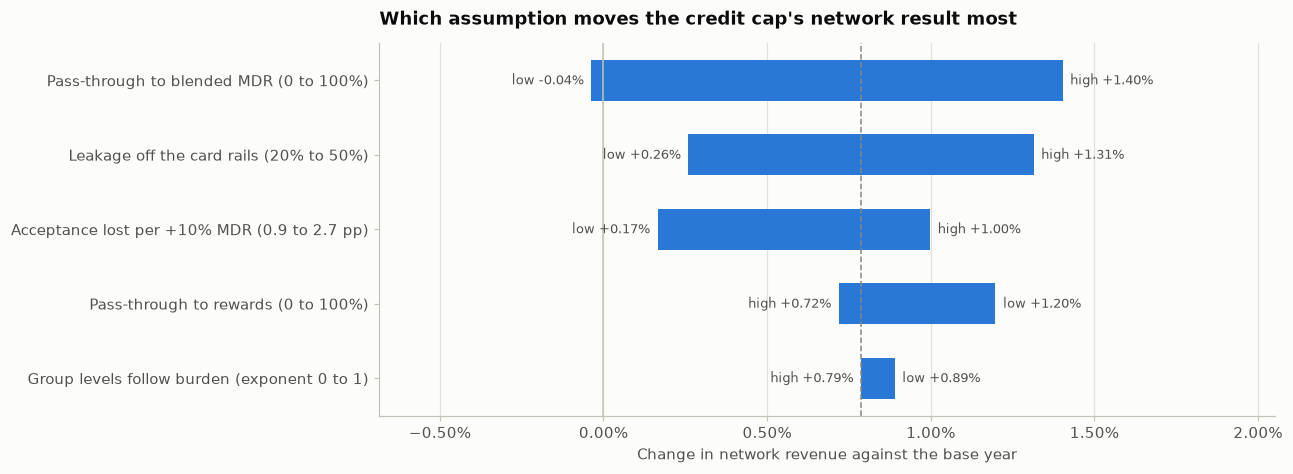

parameter,low,high,at_low,at_high,center,swing
str,f64,f64,f64,f64,f64,f64
"""simulator.blended_pass_through""",0.0,1.0,-0.000366,0.01403,0.007871,0.014396
"""elasticity.redistribution.leakage_share""",0.2,0.5,0.002599,0.013143,0.007871,0.010544
"""elasticity.acceptance.target_semi_elasticity""",0.009,0.027,0.001657,0.009983,0.007871,0.008327
"""simulator.rewards_pass_through""",0.0,1.0,0.01198,0.007193,0.007871,0.004787
"""elasticity.acceptance.level_burden_exponent""",0.0,1.0,0.0089,0.007871,0.007871,0.001029


In [10]:
ranges = {
    "simulator.blended_pass_through": (0.0, 1.0),
    "simulator.rewards_pass_through": (0.0, 1.0),
    "elasticity.redistribution.leakage_share": (0.2, 0.5),
    "elasticity.acceptance.target_semi_elasticity": (0.009, 0.027),
    "elasticity.acceptance.level_burden_exponent": (0.0, 1.0),
}
swing = tornado(state, credit_cap, ranges, metric="network_revenue_change_pct")
positions = np.arange(swing.height)
fig, axis = plt.subplots(figsize=(10.5, 4.4))
for y, row in zip(positions, swing.iter_rows(named=True), strict=True):
    low, high = sorted((row["at_low"], row["at_high"]))
    axis.barh(y, high - low, left=low, color=SERIES[0], height=0.55)
    for value, side in ((row["at_low"], "low"), (row["at_high"], "high")):
        axis.annotate(
            f"{side} {value:+.2%}",
            xy=(value, y),
            xytext=(5 if value == high else -5, 0),
            textcoords="offset points",
            ha="left" if value == high else "right",
            va="center",
            fontsize=8.5,
            color=INK_2,
        )
axis.axvline(0, color=AXIS, linewidth=1)
axis.axvline(swing["center"][0], color=MUTED, linestyle="--", linewidth=1)
axis.set_yticks(positions, [PARAMETER_LABEL[name] for name in swing["parameter"]])
axis.invert_yaxis()
axis.grid(axis="y", visible=False)
span = float(swing.select(pl.max_horizontal("at_low", "at_high").max()).item()) - float(
    swing.select(pl.min_horizontal("at_low", "at_high").min()).item()
)
axis.set_xlim(
    float(swing.select(pl.min_horizontal("at_low", "at_high").min()).item()) - 0.45 * span,
    float(swing.select(pl.max_horizontal("at_low", "at_high").max()).item()) + 0.45 * span,
)
axis.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=2))
axis.set_xlabel("Change in network revenue against the base year")
axis.set_title("Which assumption moves the credit cap's network result most")
plt.show()
swing

The pass-through to blended rates is the assumption to source first, and the only one here
that can flip the sign of the result. Leakage comes next because it decides where the volume
merchants keep comes from: the more leakage, the more of that volume would otherwise have left
the card rails rather than moved to another merchant, so the more of it is new to the network.

## 6 · Limits

- **These are not forecasts.** Each scenario rewrites 2025 with different prices; forecasting is
  Feature 8.
- **One pass, no equilibrium.** Substitutes that receive volume do not go back through the curve,
  and nobody reprices in response to the scenario.
- **Expected values.** Each merchant loses its extra abandonment probability times its volume;
  no merchant is drawn, so there is no noise to average and no tail to read.
- **Every magnitude is an assumption.** The pass-through shares, the curve's anchors, the leakage
  and the size of each lever are figures of our own: section 5 shows how far the conclusions move
  with them.

In [11]:
print(f"Notebook runtime: {time.perf_counter() - start:.1f} s")

Notebook runtime: 119.5 s
